In [ ]:
# Mid Term Practical Exam - Assignment 4
# Lanke Gauri Arvind   B2    151

# Dataset refered: data- movies.json 

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import json

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Load movie dataset from JSON file

with open("data/movies.json", "r") as file:
    movie_data = json.load(file)

print("Movie dataset loaded successfully")
print("Number of movies:", len(movie_data))

print("\nFirst movie:")
print(movie_data[0])

Movie dataset loaded successfully
Number of movies: 16

First movie:
{'id': 'M101', 'name': 'Avengers', 'description': 'Action superhero hero battle adventure science fiction'}


In [4]:
# Extract movie descriptions for Word2Vec training

movies = [
    movie["description"]
    for movie in movie_data
]

print("Movie descriptions:")
for movie in movies:
    print(movie)

Movie descriptions:
Action superhero hero battle adventure science fiction
Superhero action technology science fiction hero adventure
Romantic love relationship emotional drama
Science fiction space future technology adventure
Action crime hero police thriller battle
Comedy friendship fun entertainment
Horror ghost haunted house scary thriller
Fantasy magic wizard adventure kingdom hero
Animation family friendship adventure comedy
Mystery detective crime investigation thriller
War soldier army battle action
Romance love college friendship emotional
Science fiction robot artificial intelligence future technology
Action spy mission secret agent thriller
Comedy friendship college fun entertainment
Fantasy magic adventure kingdom hero battle


In [5]:
# Convert descriptions into tokenized sentences

sentences = [
    movie.lower().split()
    for movie in movies
]

print("Tokenized Sentences:")
print(sentences)

Tokenized Sentences:
[['action', 'superhero', 'hero', 'battle', 'adventure', 'science', 'fiction'], ['superhero', 'action', 'technology', 'science', 'fiction', 'hero', 'adventure'], ['romantic', 'love', 'relationship', 'emotional', 'drama'], ['science', 'fiction', 'space', 'future', 'technology', 'adventure'], ['action', 'crime', 'hero', 'police', 'thriller', 'battle'], ['comedy', 'friendship', 'fun', 'entertainment'], ['horror', 'ghost', 'haunted', 'house', 'scary', 'thriller'], ['fantasy', 'magic', 'wizard', 'adventure', 'kingdom', 'hero'], ['animation', 'family', 'friendship', 'adventure', 'comedy'], ['mystery', 'detective', 'crime', 'investigation', 'thriller'], ['war', 'soldier', 'army', 'battle', 'action'], ['romance', 'love', 'college', 'friendship', 'emotional'], ['science', 'fiction', 'robot', 'artificial', 'intelligence', 'future', 'technology'], ['action', 'spy', 'mission', 'secret', 'agent', 'thriller'], ['comedy', 'friendship', 'college', 'fun', 'entertainment'], ['fantasy

In [6]:
# Train Word2Vec Model
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("Word2Vec model trained successfully")

Word2Vec model trained successfully


In [7]:
# Display Vector of a Word
word = "action"

print("Vector of", word)
print(model.wv[word])

Vector of action
[ 9.2876893e-05  3.0802856e-03 -6.8206321e-03 -1.3844266e-03
  7.6725790e-03  7.3449952e-03 -3.6738424e-03  2.6407382e-03
 -8.3180722e-03  6.2082591e-03 -4.6389299e-03 -3.1641147e-03
  9.3061244e-03  8.7082427e-04  7.4914778e-03 -6.0762265e-03
  5.1618642e-03  9.9222371e-03 -8.4548099e-03 -5.1289988e-03
 -7.0627942e-03 -4.8632408e-03 -3.7726026e-03 -8.5362205e-03
  7.9564061e-03 -4.8451358e-03  8.4238844e-03  5.2583609e-03
 -6.5491726e-03  3.9534229e-03  5.4767374e-03 -7.4279197e-03
 -7.4055754e-03 -2.4736233e-03 -8.6242650e-03 -1.5820286e-03
 -4.0739964e-04  3.3037195e-03  1.4414126e-03 -8.8503095e-04
 -5.5960030e-03  1.7307352e-03 -8.9577190e-04  6.7937309e-03
  3.9692409e-03  4.5286133e-03  1.4330446e-03 -2.7036972e-03
 -4.3675131e-03 -1.0309366e-03  1.4381069e-03 -2.6473273e-03
 -7.0749666e-03 -7.8036324e-03 -9.1177458e-03 -5.9352047e-03
 -1.8434197e-03 -4.3230015e-03 -6.4631547e-03 -3.7203000e-03
  4.2903549e-03 -3.7385556e-03  8.3798673e-03  1.5356336e-03
 -7.241

In [8]:
# Find Similar Words
word = "action"
similar_words = model.wv.most_similar(
    word,
    topn=5
)

print("Words similar to", word)
for w, score in similar_words:
    print(w, ":", round(score, 4))

Words similar to action
ghost : 0.212
comedy : 0.1992
kingdom : 0.1728
army : 0.1709
thriller : 0.1703


In [9]:
# Word Analogy
result = model.wv.most_similar(
    positive=["action", "hero"],
    negative=["romance"],
    topn=5
)

print("Analogy Result:")

for word, score in result:
    print(word, ":", round(score, 4))

Analogy Result:
kingdom : 0.2254
comedy : 0.1763
emotional : 0.1647
future : 0.1622
fiction : 0.1587


In [10]:
# PCA Visualization
words = [
    "action",
    "superhero",
    "hero",
    "battle",
    "adventure",
    "romantic",
    "love",
    "drama",
    "science",
    "fiction",
    "space",
    "future",
    "comedy",
    "family",
    "friendship",
    "horror",
    "ghost",
    "magic",
    "crime",
    "detective"
]

# Keep only words available in the Word2Vec vocabulary
words = [
    w for w in words
    if w in model.wv
]

vectors = [
    model.wv[w]
    for w in words
]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)
print("PCA Coordinates:")
print(vectors_2d)

PCA Coordinates:
[[ 7.89404216e-03  5.98605632e-03]
 [-3.83997222e-03  6.55049716e-03]
 [ 1.64884528e-02  5.30961343e-05]
 [-1.92834877e-02 -9.60064565e-03]
 [-2.48357657e-02 -8.03775130e-03]
 [ 6.88435021e-03  8.73197258e-03]
 [-1.02218919e-02 -1.57743347e-02]
 [ 2.32840642e-02 -3.17458374e-02]
 [-9.14935737e-03  2.20443298e-04]
 [ 6.75243501e-03  4.53334407e-02]
 [-2.68726239e-02  1.35891770e-02]
 [ 2.17448374e-02  1.63692238e-02]
 [ 9.35874472e-03  8.69566562e-03]
 [-2.24306342e-03 -3.05680523e-02]
 [ 2.87336881e-02 -3.48738618e-04]
 [ 1.01396536e-02 -1.39447931e-02]
 [ 5.85515283e-03  1.76440611e-02]
 [ 3.21708846e-03 -1.86844636e-02]
 [-4.08184922e-02  5.55074969e-03]
 [-3.08785495e-03 -1.97667047e-05]]


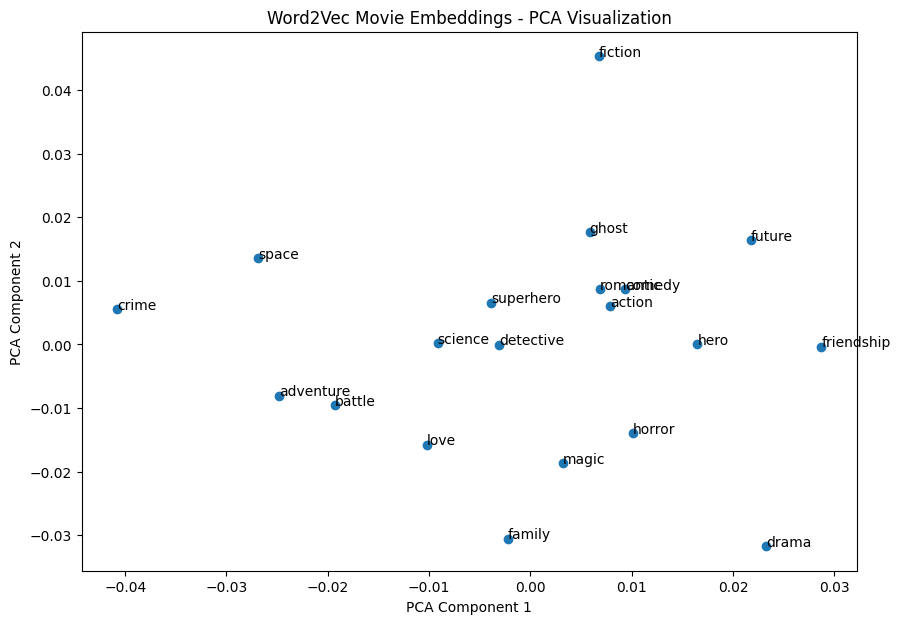

In [11]:
# Plot PCA Visualization
plt.figure(figsize=(10, 7))
plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1])
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(
    "Word2Vec Movie Embeddings - PCA Visualization"
)
plt.show()

In [12]:
# Create Movie Vector
def get_vector(text):
    words = text.lower().split()
    vectors = [
        model.wv[word]
        for word in words
        if word in model.wv
    ]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [13]:
# Movie Recommendation Function
def recommend(query):
    query_vector = get_vector(query)
    results = []
    for movie in movie_data:
        name = movie["name"]
        description = movie["description"]
        movie_vector = get_vector(description)
        score = cosine_similarity(
            [query_vector],
            [movie_vector]
        )[0][0]
        results.append(
            (name, score)
        )
    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return results

In [14]:
# Test Recommendation: Action + Superhero
query = "action superhero"
results = recommend(query)
print("Query:", query)

print("\nRecommended Movies:")
for name, score in results:
    print(
        name,
        ":",
        round(score, 4)
    )

Query: action superhero

Recommended Movies:
Avengers : 0.5936
Iron Man : 0.5886
The Dark Knight : 0.3162
Saving Private Ryan : 0.3162
Mission Impossible : 0.1435
Toy Story : 0.1372
Interstellar : 0.1097
The Matrix : 0.0887
Titanic : 0.0869
Sherlock Holmes : 0.0834
Harry Potter : 0.0377
The Lord of the Rings : -0.0088
The Hangover : -0.011
Student Love : -0.0339
3 Idiots : -0.0389
The Conjuring : -0.0602


In [15]:
# Test Recommendation: Science Fiction + Space
query = "science fiction space"
results = recommend(query)
print("Query:", query)

print("\nTop 5 Recommended Movies:")
for name, score in results[:5]:
    print(
        name,
        ":",
        round(score, 4)
    )

Query: science fiction space

Top 5 Recommended Movies:
Interstellar : 0.7478
Iron Man : 0.5094
Avengers : 0.495
The Matrix : 0.4938
Sherlock Holmes : 0.1518


In [16]:
# Test Recommendation: Romantic Love
query = "romantic love"
results = recommend(query)
print("Query:", query)

print("\nTop 5 Recommended Movies:")
for name, score in results[:5]:
    print(
        name,
        ":",
        round(score, 4)
    )

Query: romantic love

Top 5 Recommended Movies:
Titanic : 0.6061
Student Love : 0.3408
The Matrix : 0.223
3 Idiots : 0.1564
Interstellar : 0.1474


In [17]:
# Test Recommendation: Horror + Ghost
query = "horror ghost"
results = recommend(query)
print("Query:", query)

print("\nTop 5 Recommended Movies:")
for name, score in results[:5]:
    print(
        name,
        ":",
        round(score, 4)
    )

Query: horror ghost

Top 5 Recommended Movies:
The Conjuring : 0.5255
The Matrix : 0.1478
Iron Man : 0.0756
Avengers : 0.0546
Titanic : 0.0469
